# Current version : 11.A (2025-11-13)

# Libraries and directory (always run)

In [1]:
### import necessary libraries
# import anndata as ad
from datetime import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
import pandas as pd
import seaborn as sns
import scanpy as sc
import warnings
import module.xenium_preprocessing as xp
from module.config_local import dir_raw, dir_notebook

warnings.filterwarnings("ignore") 
sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 1 # errors (0), warnings (1), info (2), hints (3)
plt.rcParams["font.family"] = "Arial"
sns.set_style("white")

pd.options.display.max_rows = 250

start_time = datetime.now()

# def print_with_elapsed_time(message):
#     elapsed_time = datetime.now() - start_time
#     elapsed_seconds = elapsed_time.total_seconds()
#     print(f"[{elapsed_seconds:.2f} seconds] {message}")

In [2]:
print(f"pandas version: {pd.__version__}")
print(f"scanpy version: {sc.__version__}")

pandas version: 2.3.3
scanpy version: 1.11.5


In [3]:
from module.misc import sample_name_import

# name_dir = "circa-SD"
# name_dir = "all-samples-C0"
# name_dir = 'all-samples-C123'
name_dir = 'liver-cancer'

samples_ids = sample_name_import(name_dir)

print(len(samples_ids))
print(samples_ids)

2
['hLiver-cancer', 'hLiver-nondiseased']


# Data pre-processing

## Import data from Xenium output

In [4]:
# from module.xenium_preprocessing import import_xenium

adata = xp.import_xenium(
                      samples_ids,
                      name_dir,
                      trans_min = 40,
                      trans_max = 4000,
                      remove_noise = True,
                      MMC = False,
                      use_cell_list = False,
                      )

## Noise evaluation ##
Start Sample : hLiver-cancer
1  /  2
threshold =  309.1
nb of gene under threshold :  18
 
Start Sample : hLiver-nondiseased
2  /  2
threshold =  101.905
nb of gene under threshold :  0
 
Will exclude 0 genes
 
## Start importation ##
Proportion of cells concerved after filtering = 91.70% (149136 cells)
Sample hLiver-cancer done
 
Proportion of cells concerved after filtering = 84.76% (202815 cells)
Sample hLiver-nondiseased done
 
Read all 2 samples


In [ ]:
# If you don't want to use MMC (brain annotation), continue to the next section : 'Quality Metrics'

# If you want to, continue to the next section AND while it runs, run MapMyCell with the individual h5ad generated.
# Then put the .csv files obtained in the "Correlation_Mapping" folder, renamed as: {sample}_CorrelationMapping.csv
# They will be used on the next notebook for annotations


## Quality metrics

In [5]:
sc.pp.calculate_qc_metrics(adata,  percent_top=(10, 20, 50, 150), inplace=True)

In [6]:
cprobes = (adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100)
cwords = (adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.023314040413550504
Negative decoding count % : 0.002641615291360571


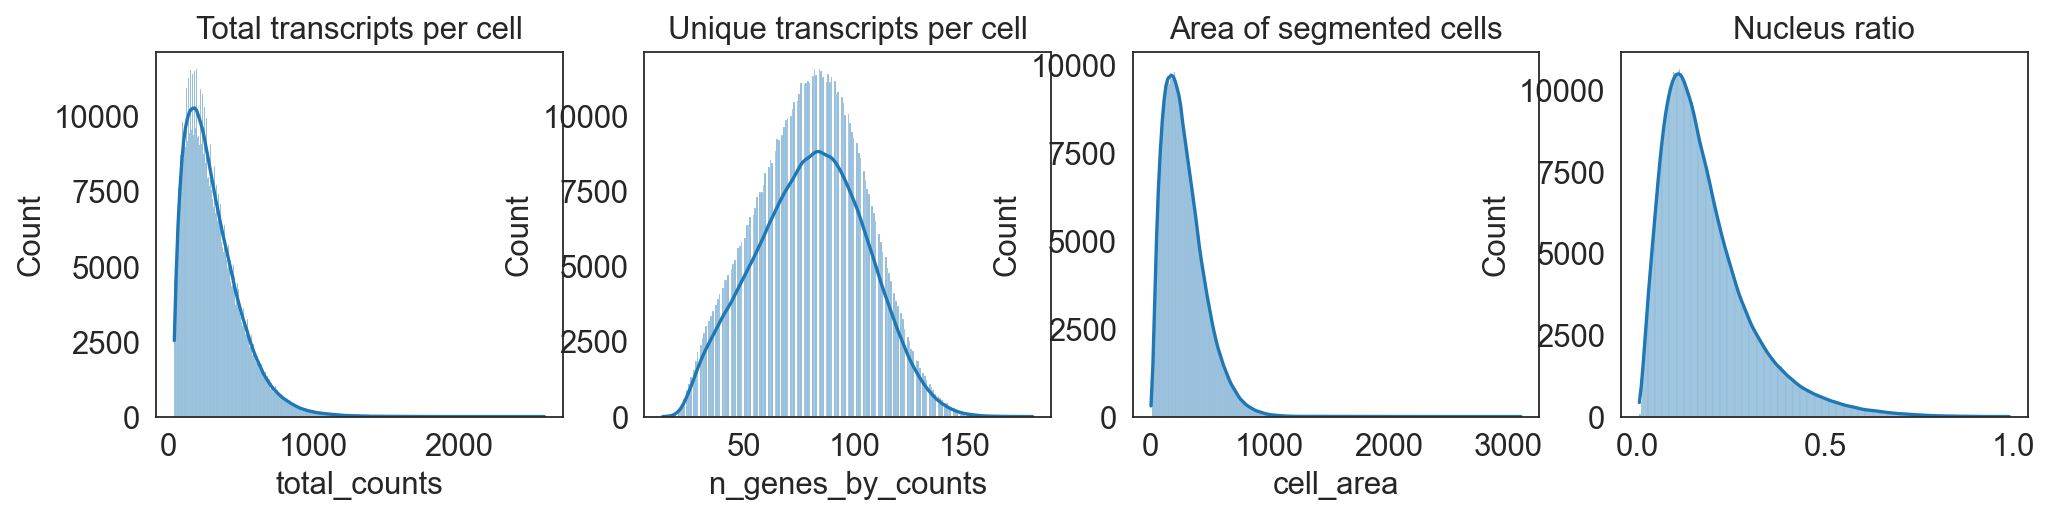

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(15, 3))

axs[0].set_title("Total transcripts per cell")
sns.histplot(adata.obs["total_counts"],kde=True,ax=axs[0])

axs[1].set_title("Unique transcripts per cell")
sns.histplot(adata.obs["n_genes_by_counts"],kde=True,ax=axs[1])

axs[2].set_title("Area of segmented cells")
sns.histplot(adata.obs["cell_area"], kde=True, ax=axs[2])

axs[3].set_title("Nucleus ratio")
sns.histplot(adata.obs["nucleus_area"] / adata.obs["cell_area"], kde=True,ax=axs[3])

plt.savefig(f"{dir_notebook}/plot/{name_dir}/{name_dir}_quality-metrics_Xeniumcellsegmentation.svg",
            dpi = 300, transparent = True, format = 'svg')

In [ ]:
adata.obs['run'] = adata.obs_names.map(lambda name: name.split('-')[0]) ### If multiple runs combined in one dataset. Adapt separation sign to the actual name

if adata.obs['run'].nunique() > 1:
    for run in adata.obs['run'].unique():
        adata_sub = adata[adata.obs['run']==run]

        fig, axs = plt.subplots(1, 4, figsize=(15, 3))

        axs[0].set_title("Total transcripts per cell")
        sns.histplot(adata_sub.obs["total_counts"],kde=True,ax=axs[0])

        axs[1].set_title("Unique transcripts per cell")
        sns.histplot(adata_sub.obs["n_genes_by_counts"],kde=True,ax=axs[1])

        axs[2].set_title("Area of segmented cells")
        sns.histplot(adata_sub.obs["cell_area"], kde=True, ax=axs[2])

        axs[3].set_title("Nucleus ratio")
        sns.histplot(adata_sub.obs["nucleus_area"] / adata_sub.obs["cell_area"], kde=True,ax=axs[3])

        plt.savefig(f"{dir_notebook}/plot/{name_dir}/{run}_{name_dir}_quality-metrics.svg")

## Normalize, PCA, UMAP, clustering

### Automatic process

Start
Normalize done
log1p done
Start Clustering
PCA done


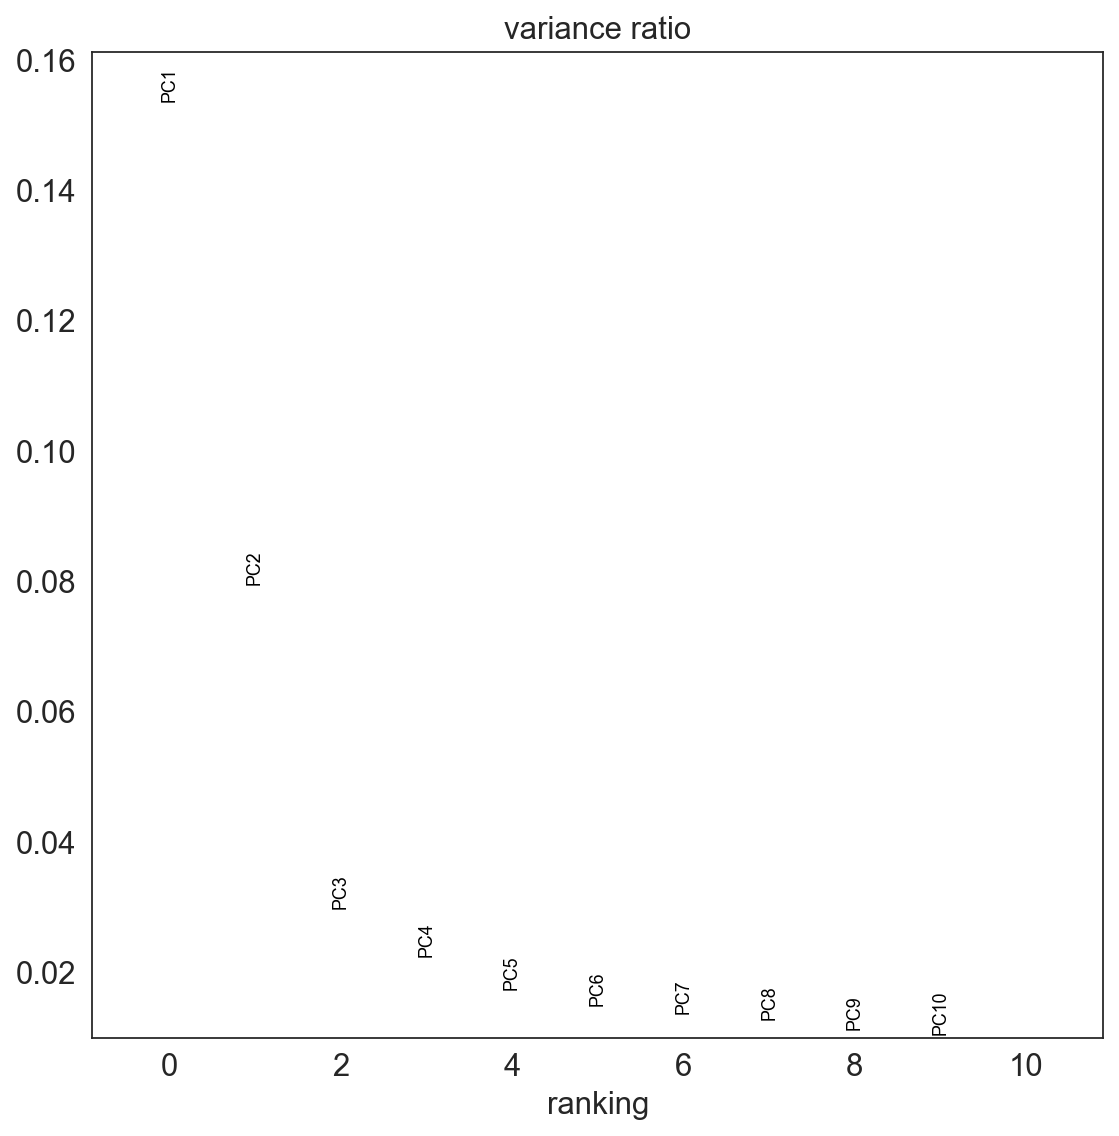

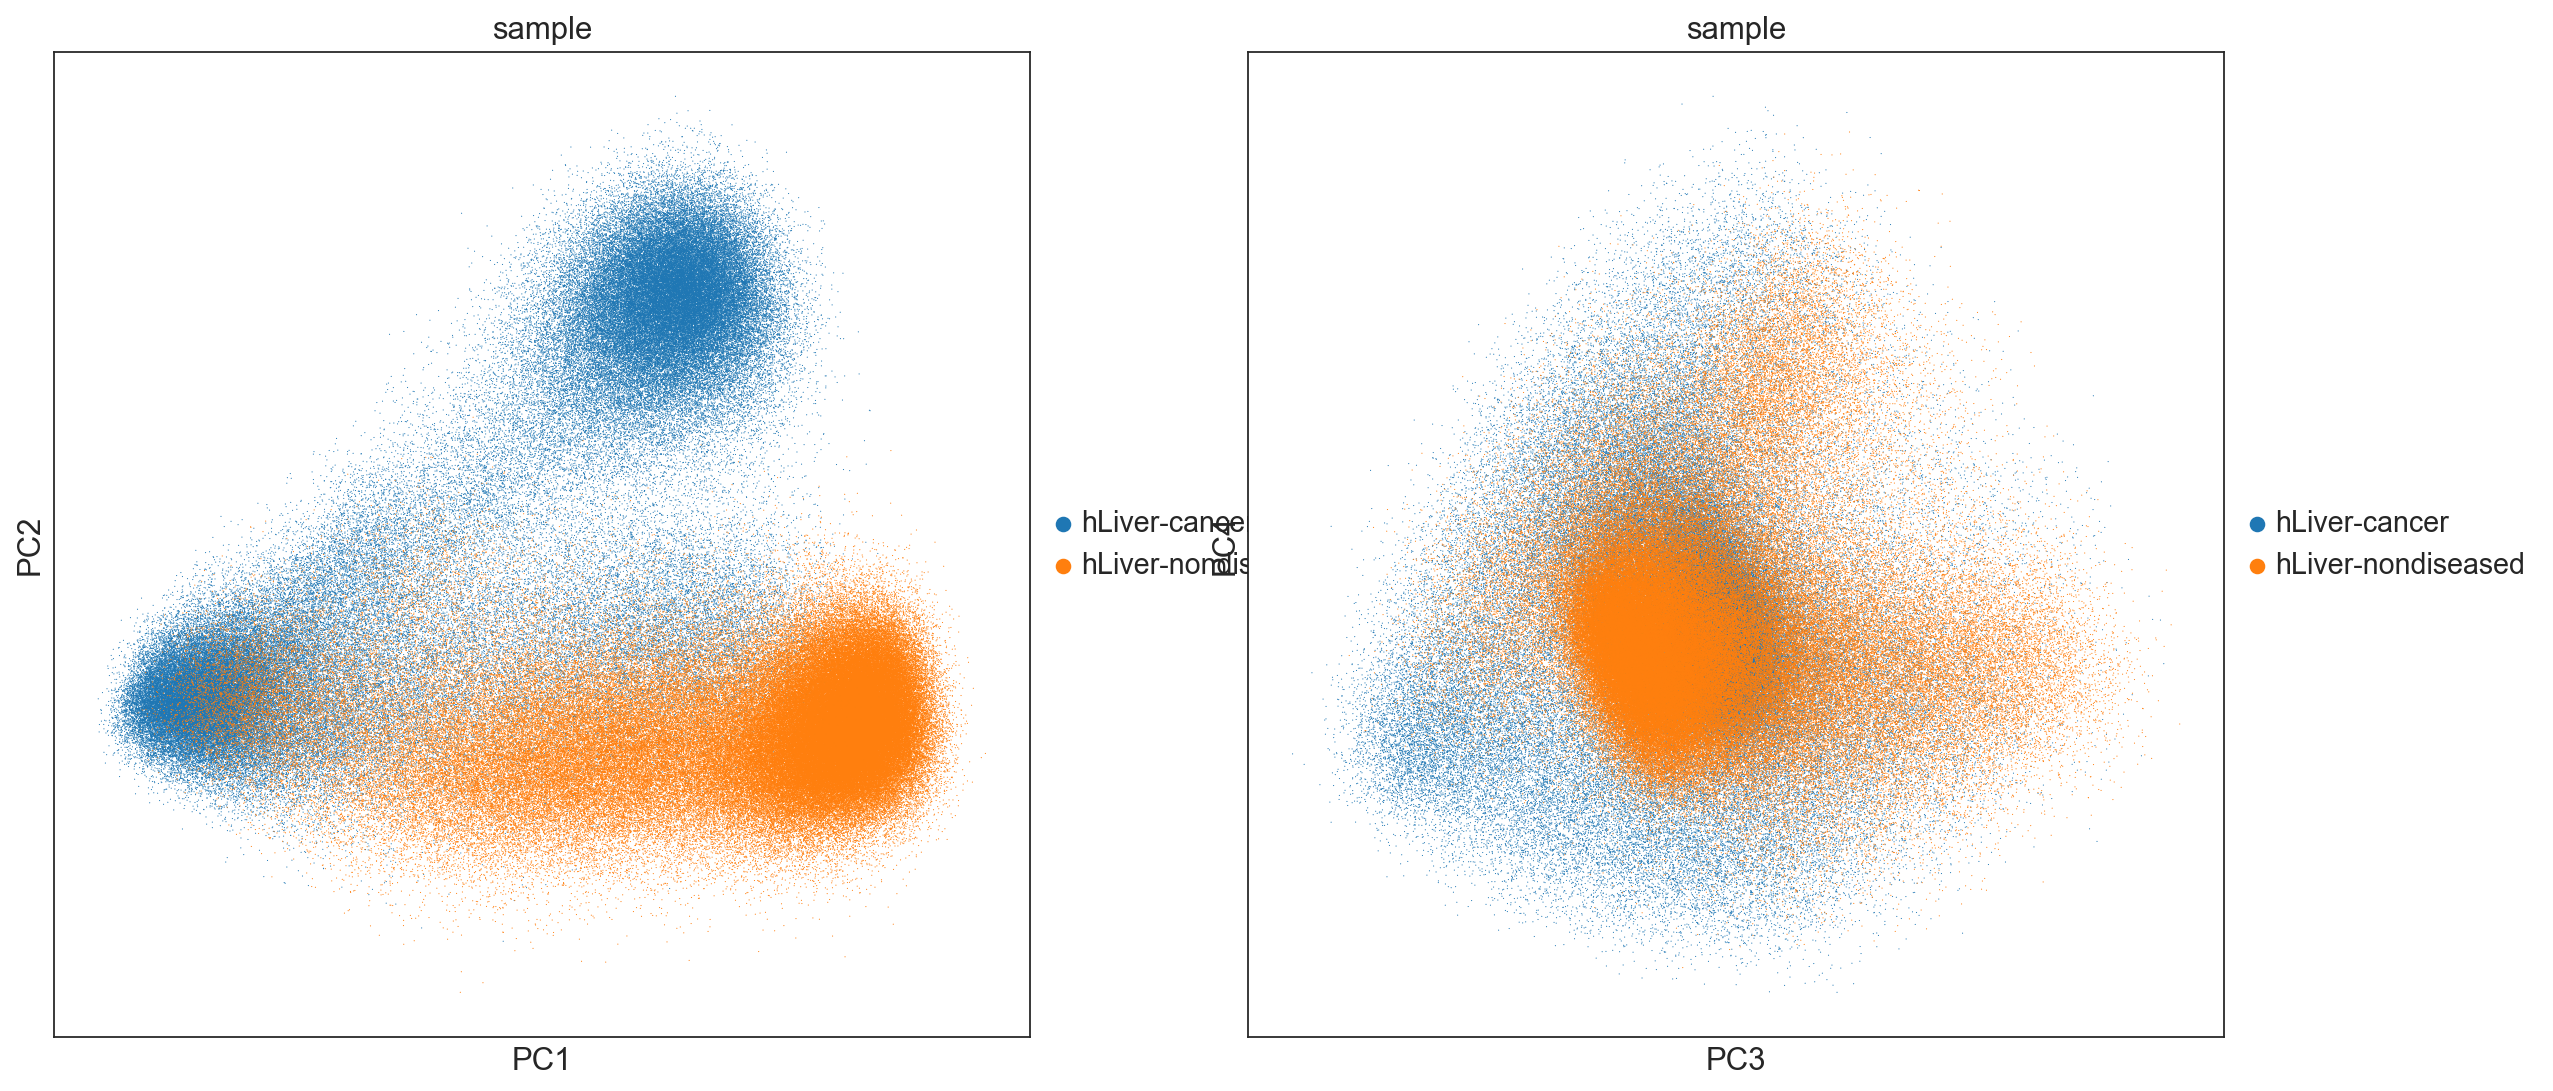

Neighbors done
UMAP done


ImportError: Please install the leiden algorithm: `conda install -c conda-forge leidenalg` or `pip3 install leidenalg`.

In [8]:
xp.norm_to_cluster(adata,
                name_dir,
                leiden_resolution = 0.7,
                pca_compo = 10,
                )

### Manual process

In [ ]:
### Normalize, log1p, scale, PCA, and UMAP
start_time = datetime.now()
print(f"Start")
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
print(f"Normalize done")
sc.pp.log1p(adata)
print(f"log1p done")

In [ ]:
if not os.path.exists(f"{dir_notebook}/h5ad/{name_dir}/"):
   os.makedirs(f"{dir_notebook}/h5ad/{name_dir}/")
adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_norm.h5ad.gz", compression='gzip')

# adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_norm.h5ad.gz")

In [ ]:
start_time = datetime.now()
print(f"Start")
sc.pp.pca(adata, n_comps = 10)
print(f"PCA done")

In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
sc.pl.pca(
    adata,
    color=["sample","sample"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=1,
)

In [ ]:
if not os.path.exists(f"{dir_notebook}/h5ad/{name_dir}/"):
   os.makedirs(f"{dir_notebook}/h5ad/{name_dir}/")
adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_norm.h5ad.gz", compression='gzip')

# adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_norm.h5ad.gz")

In [ ]:
import scanpy.external as sce
adata.obs['run'] = adata.obs_names.map(lambda name: name.split('-')[0]) ### If multiple runs combined in one dataset. Adapt separation sign to the actual name

if adata.obs['run'].nunique() > 1:
    sce.pp.harmony_integrate(adata, key = 'run', basis = f"X_pca",  adjusted_basis = f"X_pca_harmony") ### Will overwrite original pca. Change "adjusted_basis" name to save both.
    print(f"Harmony done")
    sc.pl.pca(
        adata,
        color=["sample","sample"],
        dimensions=[(0, 1), (2, 3)],
        ncols=2,
        size=1,
        )

In [ ]:
adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_norm.h5ad.gz", compression='gzip')

# adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_norm.h5ad.gz")

In [ ]:
start_time = datetime.now()
print(f"Start")
sc.pp.neighbors(adata)
print(f"Neighbors done")
sc.tl.umap(adata, min_dist = 1)
print(f"UMAP done")

In [ ]:
adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_norm.h5ad.gz", compression='gzip')

# adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_norm.h5ad.gz")

In [ ]:
start_time = datetime.now()
print(f"Start")
sc.tl.leiden(adata, resolution = 0.2) ### Use a higher resolution value to obtain more clusters. They can be adjusted/merged/subclustered later
print('End of clustering')

In [ ]:
from matplotlib.pyplot import rc_context
with rc_context({"figure.figsize": (10, 10)}):
    sc.pl.umap(
        adata,
        color="leiden",
        add_outline=False,
        legend_loc="on data",
        legend_fontsize=12,
        legend_fontoutline=2,
        frameon=False,
        palette="tab20b",
        size = 1
    )

In [ ]:
import module.dataviz_analysis as da
da.cluster_plot(adata,
            name_dir=name_dir,
            dir_notebook=dir_notebook,
            cluster_to_use='leiden',
            cluster_to_map=['all'])

In [ ]:
cluster_to_use = "leiden"

adata.obs[cluster_to_use] = adata.obs[cluster_to_use].astype(str)

sc.tl.rank_genes_groups(adata, groupby=cluster_to_use, method="wilcoxon", tie_correct = True)

print('Ranking done')
sc.tl.dendrogram(adata, groupby=cluster_to_use)
sc.pl.rank_genes_groups_dotplot(adata, groupby=cluster_to_use,
                                values_to_plot="logfoldchanges",
                                min_logfoldchange= 0.26,
                                # standard_scale="var",
                                n_genes=2, dendrogram = True)

In [ ]:
sc.tl.dendrogram(adata, groupby=cluster_to_use)
sc.pl.rank_genes_groups_dotplot(adata, groupby=cluster_to_use,
                                values_to_plot="logfoldchanges",
                                min_logfoldchange= 0.26,
                                #standard_scale="var",
                                n_genes=5, dendrogram = True)

## Save adata

In [ ]:
if 'leiden_colors' in adata.obs.columns:
   adata.obs.drop('leiden_colors', axis=1, inplace=True)

adata.write(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_clusters.h5ad.gz", compression='gzip')

In [ ]:
adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_clusters.h5ad.gz")
# adata = sc.read_h5ad(f"{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz")

## Create a normalised datamatrix

In [ ]:
# Create a normalised datamatrix for saving to disk as a csv file - rows are cells, columns are genes
df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
df.shape

from module.xenium_preprocessing import add_annotations

df = add_annotations(adata, df)

### Extract normalized expression and clusters for individual cells
if not os.path.exists(f"{dir_notebook}/csv/{name_dir}/"):
   os.makedirs(f"{dir_notebook}/csv/{name_dir}/")

df.to_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_normalized_counts.parquet")

# End of this notebook

Next step : clusters annotation

[v11B_Xenium_annotation_n_subsclustering](./v11B_Xenium_annotation_n_subsclustering.ipynb)